Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\neurosynth_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\neurosynth_cerebellum.svg


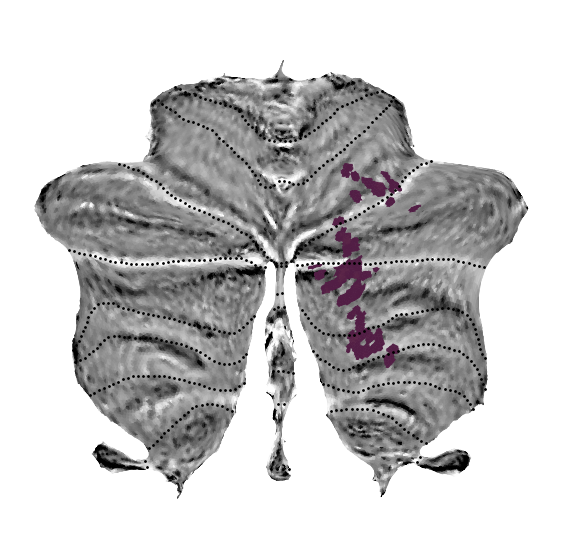

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\pmap_lifg_g0_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\pmap_lifg_g0_cerebellum.svg


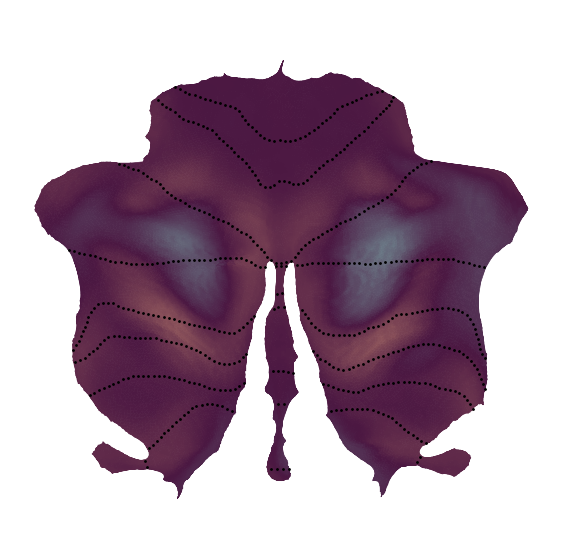

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\pmap_lstg_g0_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\pmap_lstg_g0_cerebellum.svg


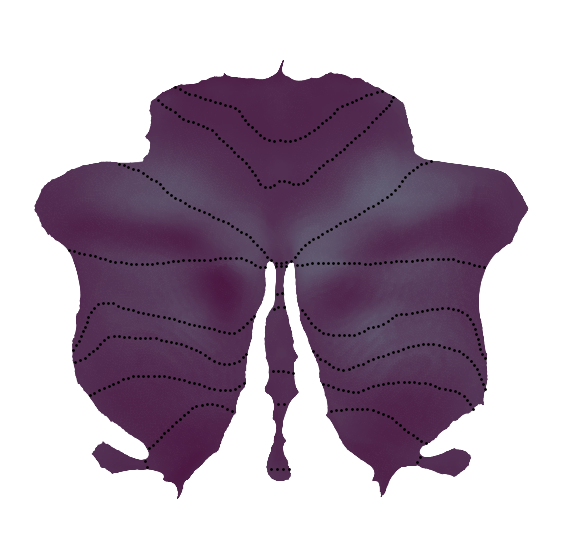

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\pmap_lifg_g1_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\pmap_lifg_g1_cerebellum.svg


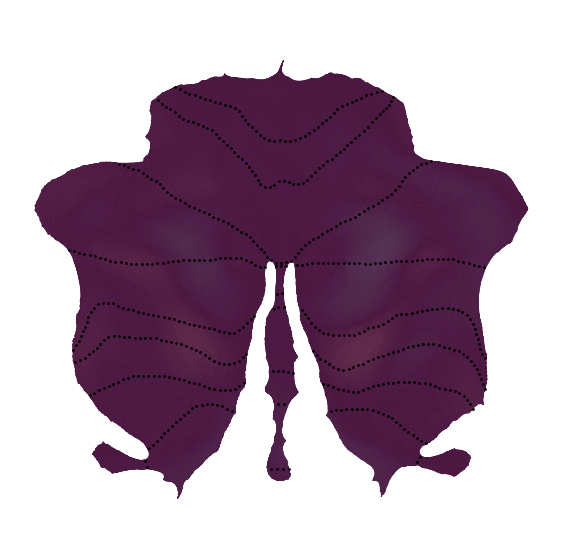

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\pmap_lstg_g1_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\pmap_lstg_g1_cerebellum.svg


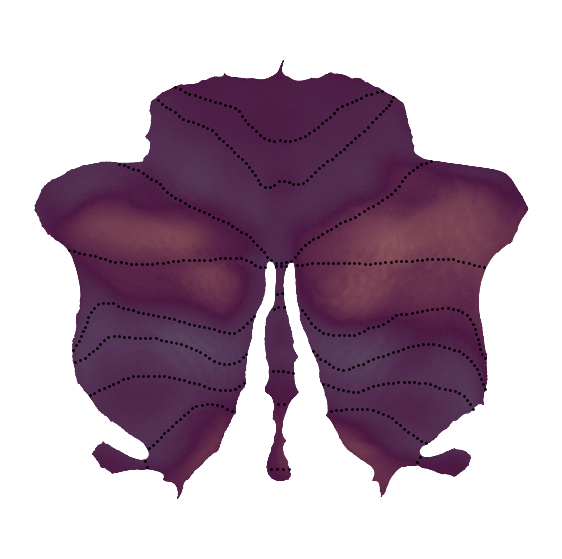

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lifg_ic1_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lifg_ic1_cerebellum.svg


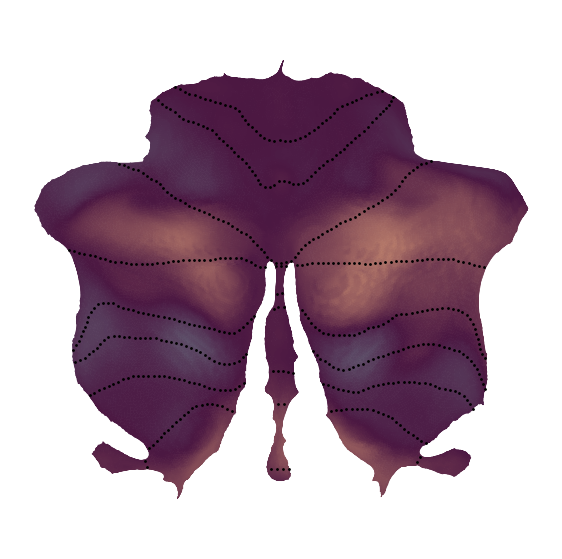

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lifg_ic2_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lifg_ic2_cerebellum.svg


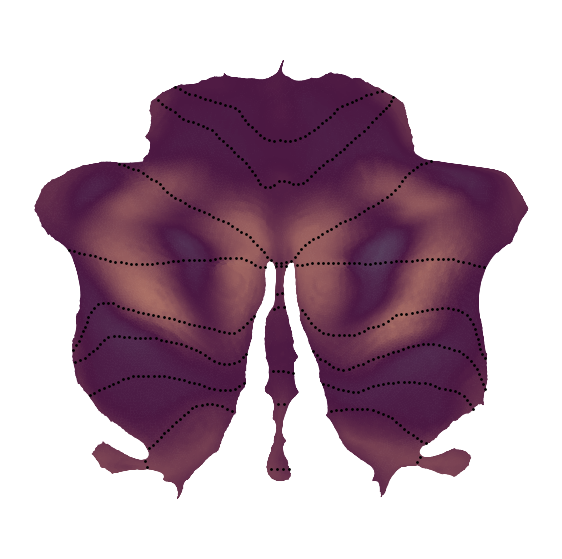

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lifg_ic3_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lifg_ic3_cerebellum.svg


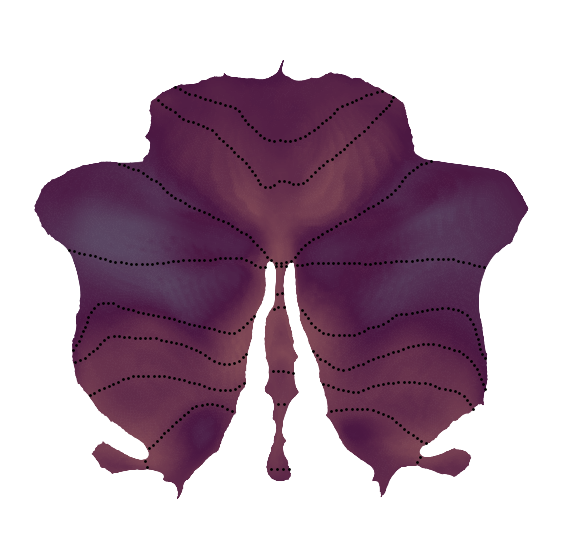

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lstg_ic1_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lstg_ic1_cerebellum.svg


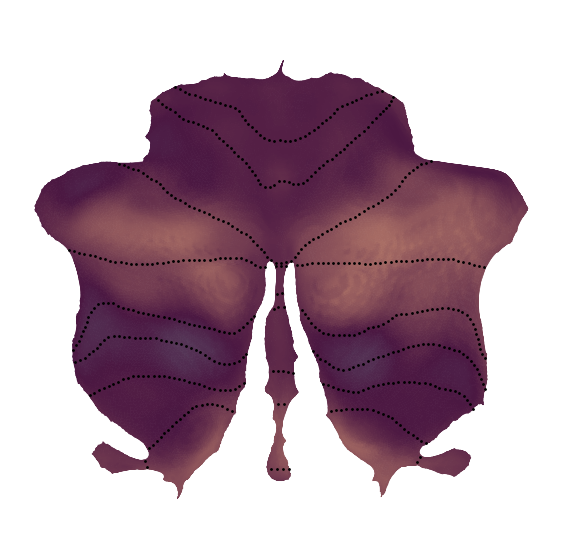

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lstg_ic2_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lstg_ic2_cerebellum.svg


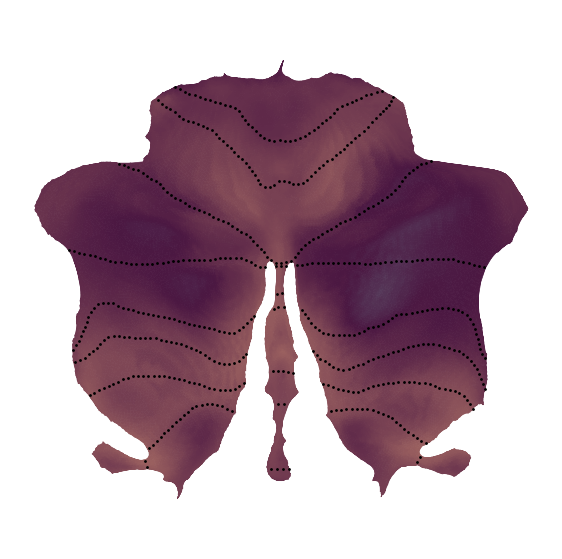

sizeof_hdr should be 348; set sizeof_hdr to 348


Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lstg_ic3_cerebellum.png
Saved: C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\lstg_ic3_cerebellum.svg


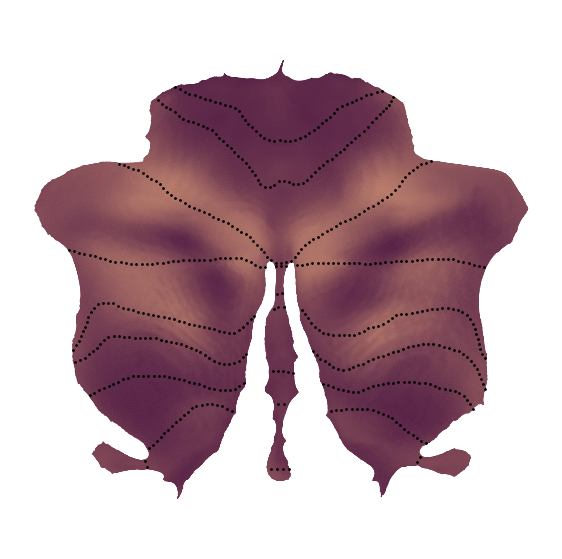

In [ ]:
import os
import SUITPy.flatmap as flatmap
import matplotlib.pyplot as plt
import nibabel as nb
import numpy as np
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

windows = True

if windows:
    base_dir = "P:/workspaces/lg-ukbiobank/projects/"
else:
    base_dir = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/"

nifti_path = os.path.join(base_dir, "nifti_avg")

neurosynth_fn = os.path.join(base_dir, "language_association-test_z_FDR_0.01_231027.nii.gz")

pmaps = [os.path.join(base_dir, "mean_gs", "all_data_lifg_g1_pmap_mean.nii.gz"),
           os.path.join(base_dir, "mean_gs", "all_data_lstg_g1_pmap_mean.nii.gz")]
pmaps_g1 = [os.path.join(base_dir, "mean_gs", "all_data_lifg_g2_pmap_mean.nii.gz"),
           os.path.join(base_dir, "mean_gs", "all_data_lstg_g2_pmap_mean.nii.gz")]


lifg_img = os.path.join(nifti_path, "g1_pmap_lifg_oIC.nii.gz")
lstg_img = os.path.join(nifti_path, "g1_pmap_lstg_oIC.nii.gz")

lifg_g2_img = os.path.join(nifti_path, "g2_pmap_lifg_oIC.nii.gz")
lstg_g2_img = os.path.join(nifti_path, "g2_pmap_lstg_oIC.nii.gz")


colors = ["#80BBB4",  "#4B1742", "#F7B682"]
#colors = [ '#ED6B06',  "whitesmoke", '#00786A']
palette = LinearSegmentedColormap.from_list("custom_palette", colors)

# Function to plot and save cerebellar flatmap
def plot_cerebellar_flatmap(img_path, title, output_filename, cmap=None, threshold=None, volume_idx=None):
    """
    Plot cerebellar flatmap using SUITPy and save as PNG and SVG
    
    Parameters:
    img_path: path to nifti file
    title: plot title
    output_filename: base filename for output (without extension)
    threshold: threshold for plotting
    volume_idx: specific volume index for 4D images (None for 3D)
    """
    
    # Check if file exists
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"File not found: {img_path}")
    
    # Load the image
    img = nb.load(img_path)

    if not cmap:
        cmap="coolwarm"
    
    # Extract specific volume if needed
    if len(img.shape) == 3:
        img_data = img.get_fdata()[:, :, :]
        max_val = np.max(np.abs(img_data))
        img = nb.Nifti1Image(img_data, img.affine, img.header)
        gii_data = flatmap.vol_to_surf(img, space='FSL')
    elif len(img.shape) == 4:
        if volume_idx is not None:
            img_data = img.get_fdata()[:, :, :, volume_idx]
            max_val = np.max(np.abs(img_data))
            img = nb.Nifti1Image(img_data, img.affine, img.header)
            gii_data = flatmap.vol_to_surf(img, space='FSL')
        else:
            raise ValueError(f"Volume index specified but image is not 4D: {img_path}")
    
    
    # Create the plot
    flatmap.plot(data=gii_data, 
                cmap=cmap,
                threshold=threshold,
                cscale=[-max_val, max_val],
                new_figure=True,
                colorbar=False,  # Hide colorbar as requested
                render='matplotlib')
    
    # Set title
    #plt.title(title, fontsize=14, fontweight='bold')
    
    # Save as PNG and SVG
    png_path = os.path.join(base_dir, "figs_new", f"{output_filename}.png")
    svg_path = os.path.join(base_dir, "figs_new", f"{output_filename}.svg")
    
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    plt.savefig(svg_path, format='svg', bbox_inches='tight')
    
    print(f"Saved: {png_path}")
    print(f"Saved: {svg_path}")
    
    plt.show()

plot_cerebellar_flatmap(img_path=neurosynth_fn,
                        title = "Neurosynth",
                        output_filename="neurosynth_cerebellum",
                        cmap=palette,
                        threshold = 1e-6)

# Plot PMAP files
pmap_titles = ["PMAP LIFG", "PMAP LSTG"]
pmap_outnames = ["pmap_lifg_g1", "pmap_lstg_g1"]

for pmap_path, title, filename in zip(pmaps, pmap_titles, pmap_outnames):
    plot_cerebellar_flatmap(pmap_path, title, filename+"_cerebellum", cmap=palette)

pmap_titles = ["PMAP LIFG", "PMAP LSTG"]
pmap_outnames = ["pmap_lifg_g2", "pmap_lstg_g2"]

for pmap_path, title, filename in zip(pmaps_g1, pmap_titles, pmap_outnames):
    plot_cerebellar_flatmap(pmap_path, title, filename+"_cerebellum", cmap=palette)

# Plot LIFG IC files (3 volumes)
lifg_titles = ["LIFG IC 1", "LIFG IC 2", "LIFG IC 3"]
lifg_outnames = ["lifg_ic1", "lifg_ic2", "lifg_ic3"]

for i, (title, filename) in enumerate(zip(lifg_titles, lifg_outnames)):
    plot_cerebellar_flatmap(lifg_img, title, filename+"_cerebellum", cmap=palette, volume_idx=i)

# Plot LSTG IC files (3 volumes)
lstg_titles = ["LSTG IC 1", "LSTG IC 2", "LSTG IC 3"]
lstg_outnames = ["lstg_ic1", "lstg_ic2", "lstg_ic3"]

for i, (title, filename) in enumerate(zip(lstg_titles, lstg_outnames)):
    plot_cerebellar_flatmap(lstg_img, title, output_filename=filename+"_cerebellum",  cmap=palette, volume_idx=i)

lifg_titles = ["LIFG IC 1", "LIFG IC 2", "LIFG IC 3"]
lifg_outnames = ["g2_lifg_ic1", "g2_lifg_ic2", "g2_lifg_ic3"]

for i, (title, filename) in enumerate(zip(lifg_titles, lifg_outnames)):
    plot_cerebellar_flatmap(lifg_g2_img, title, filename+"_cerebellum", cmap=palette, volume_idx=i)

# Plot LSTG IC files (3 volumes)
lstg_titles = ["LSTG IC 1", "LSTG IC 2", "LSTG IC 3"]
lstg_outnames = ["g2_lstg_ic1", "g2_lstg_ic2", "g2_lstg_ic3"]

for i, (title, filename) in enumerate(zip(lstg_titles, lstg_outnames)):
    plot_cerebellar_flatmap(lstg_g2_img, title, output_filename=filename+"_cerebellum",  cmap=palette, volume_idx=i)